# Loan Approval Kaggle EDA

## Objective
Explore the Kaggle loan approval training dataset, understand its structure, inspect missing values, study target distribution, and prepare it for preprocessing and modeling.

## Dataset
`../Dataset/LoanApprovalKaggle/train_u6lujuX_CVtuZ9i.csv`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
df = pd.read_csv("../Dataset/LoanApprovalKaggle/train_u6lujuX_CVtuZ9i.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [2]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.info()

Shape: (614, 13)

Columns:
 Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

Missing values:
 Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Duplicate rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-nul

## Initial Observations
- This dataset has a loan-domain target column: `Loan_Status`.
- It contains mixed numerical and categorical variables.
- Missing values are present, so preprocessing will be important.


In [3]:
df.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loan_ID,614,614,LP001002,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,601,2,Male,489,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Married,611,2,Yes,398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,599,4,0,345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,614,2,Graduate,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Self_Employed,582,2,No,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ApplicantIncome,614.0,NaN,NaN,NaN,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.0,81000.0
CoapplicantIncome,614.0,NaN,NaN,NaN,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,NaN,NaN,NaN,146.412162,85.587325,9.0,100.0,128.0,168.0,700.0
Loan_Amount_Term,600.0,NaN,NaN,NaN,342.0,65.12041,12.0,360.0,360.0,360.0,480.0


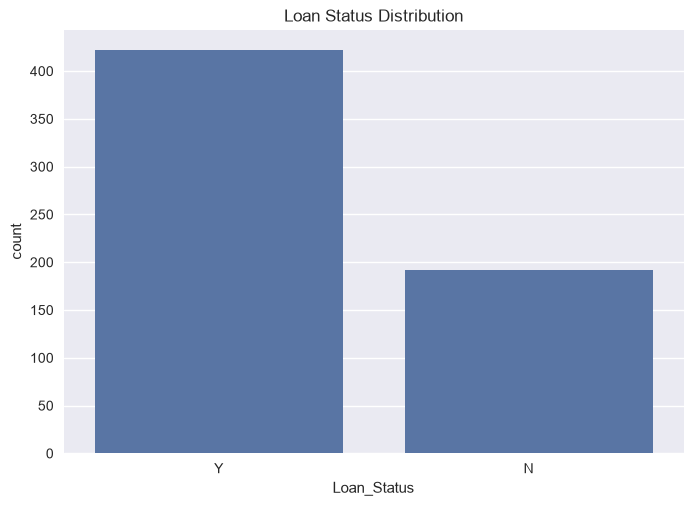

In [4]:
sns.countplot(x="Loan_Status", data=df)
plt.title("Loan Status Distribution")
plt.show()

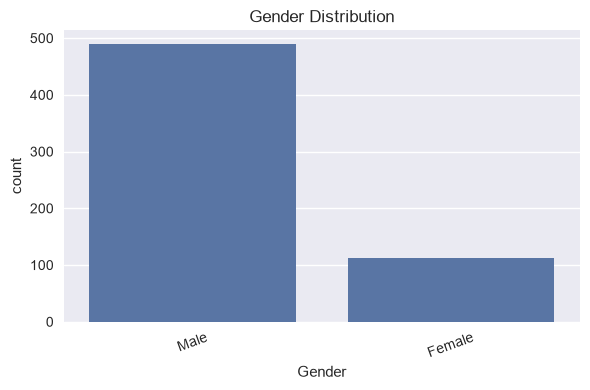

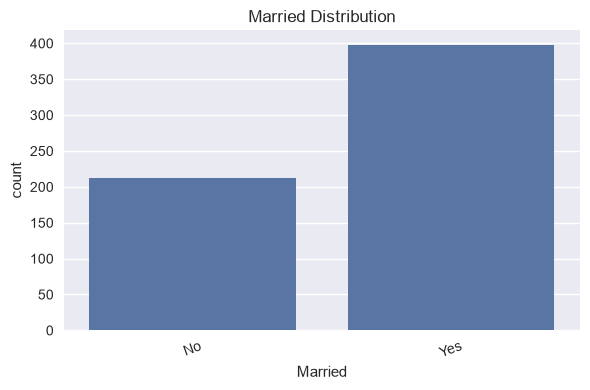

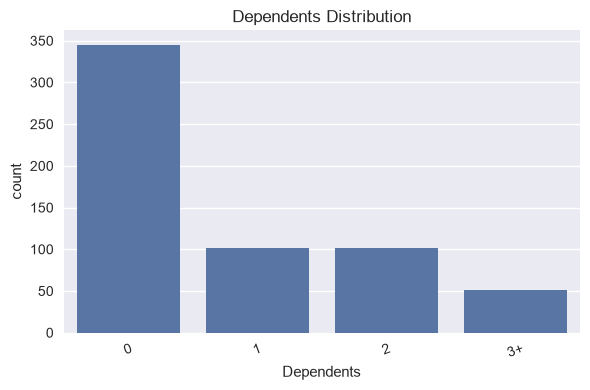

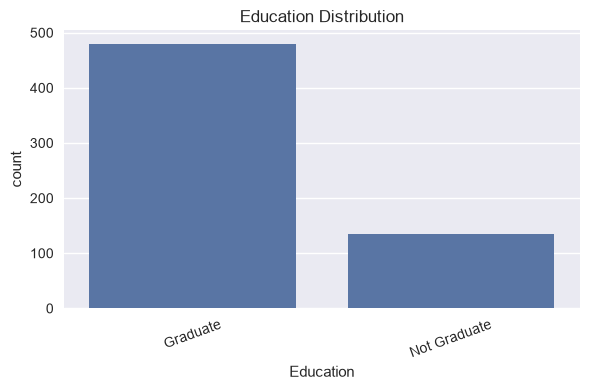

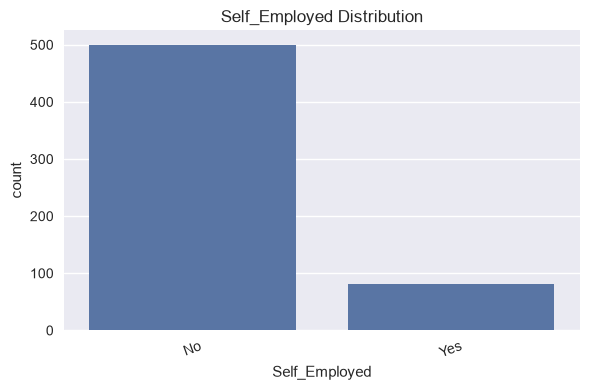

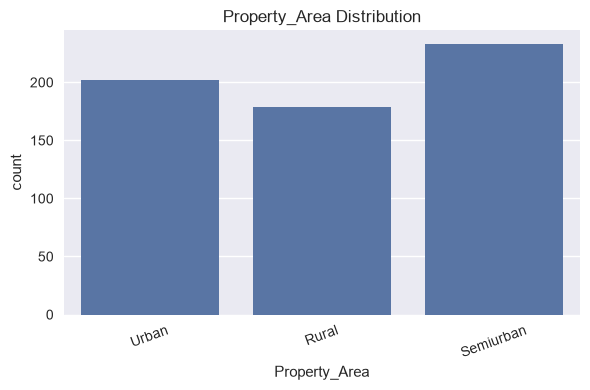

In [5]:
categorical_cols = ["Gender", "Married", "Dependents", "Education", "Self_Employed", "Property_Area"]
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

In [ ]:
numeric_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term", "Credit_History"]
df[numeric_cols].hist(figsize=(12, 8), bins=20)
plt.suptitle("Numerical Feature Distributions")
plt.tight_layout()
plt.show()

In [ ]:
plot_df = df.copy()
plot_df["Loan_Status_Label"] = plot_df["Loan_Status"].map({"Y": "Approved", "N": "Rejected"})

plt.figure(figsize=(7, 4))
sns.boxplot(x="Loan_Status_Label", y="ApplicantIncome", data=plot_df)
plt.title("Applicant Income vs Loan Status")
plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(x="Loan_Status_Label", y="LoanAmount", data=plot_df)
plt.title("Loan Amount vs Loan Status")
plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(x="Loan_Status_Label", y="Credit_History", data=plot_df)
plt.title("Credit History vs Loan Status")
plt.show()

## EDA Conclusion
- The dataset is realistic and suitable for a loan approval capstone.
- Missing values need treatment before modeling.
- `Credit_History` is expected to be an important predictor.
- This dataset is a strong candidate for the final project workflow.


# Data Preprocessing

## Objective
Clean the selected Kaggle loan dataset, handle missing values, encode features, and prepare a reusable preprocessing pipeline for model training and deployment.

## Why This Step Is Important
- The dataset contains missing values across multiple columns.
- The model needs consistent transformations during both training and deployment.
- The deployment app should reuse the same saved preprocessing object used during model training.


In [ ]:
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = Path.cwd().resolve().parent if Path.cwd().name.lower() == 'notebook' else Path.cwd().resolve()
ARTIFACTS_DIR = ROOT / 'artifacts'
ARTIFACTS_DIR.mkdir(exist_ok=True)

final_df = pd.read_csv(ROOT / 'Dataset' / 'LoanApprovalKaggle' / 'train_u6lujuX_CVtuZ9i.csv')
final_df.head()

In [ ]:
print('Missing values before preprocessing:')
print(final_df.isnull().sum())

print('\nDuplicate rows:', final_df.duplicated().sum())

final_df = final_df.drop_duplicates().copy()
final_df['Dependents'] = final_df['Dependents'].replace('3+', '3')
final_df['Loan_Status'] = final_df['Loan_Status'].map({'Y': 1, 'N': 0})
final_df.head()

## Preprocessing Design
- `Loan_ID` is removed because it is only an identifier.
- Numerical columns use median imputation and scaling.
- Categorical columns use most-frequent imputation and one-hot encoding.
- The final preprocessing object will be saved as `artifacts/preprocessor.pkl`.


In [ ]:
X = final_df.drop(columns=['Loan_Status', 'Loan_ID'])
y = final_df['Loan_Status']

categorical_features = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
numerical_features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_features),
    ('cat', cat_pipeline, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print('Training features shape after preprocessing:', X_train_processed.shape)
print('Testing features shape after preprocessing:', X_test_processed.shape)

# Model Training

The following block trains three baseline classifiers for the selected Kaggle dataset and compares them using standard classification metrics.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    preds = model.predict(X_test_processed)
    fitted_models[name] = model
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1 Score': f1_score(y_test, preds)
    })
    print(f'\n{name} Classification Report\n')
    print(classification_report(y_test, preds))

results_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False)
results_df

In [ ]:
best_model_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_model_name]

print('Best model:', best_model_name)
print(results_df.iloc[0])

# Save Deployment Artifacts

This step saves the final preprocessing object and selected model in the deployment layout expected by `application.py`.


In [ ]:
import joblib

joblib.dump(preprocessor, ARTIFACTS_DIR / 'preprocessor.pkl')
joblib.dump(best_model, ARTIFACTS_DIR / 'model.pkl')

print('Saved:', ARTIFACTS_DIR / 'preprocessor.pkl')
print('Saved:', ARTIFACTS_DIR / 'model.pkl')

## Preprocessing and Training Conclusion
- The selected Kaggle dataset is now prepared for end-to-end modeling.
- The preprocessing pipeline is reusable for both evaluation and deployment.
- After running the notebook successfully, the Flask deployment app can use `artifacts/model.pkl` and `artifacts/preprocessor.pkl` directly.
